[(220.0, 1263510772.324672)]


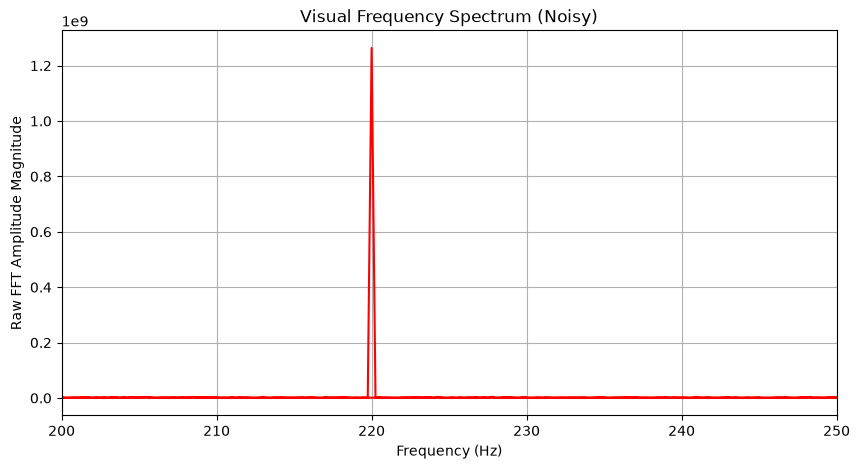

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks, butter, sosfiltfilt

#Generating sound data
samplerate = 44100
duration = 4.0
t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)

pitchfreq = 220
puresine = np.sin(2 * np.pi * pitchfreq * t)

np.random.seed(2)
whtnoise = np.random.normal(0, 0.3, size=len(t))

noisysignal = whtnoise + puresine

maxamp = np.max(np.abs(noisysignal))
normfloats = noisysignal / maxamp
noisy_sixteenbit = np.int16(normfloats * 32767) #16 bits spread on either side of 0
wavfile.write('hissysignal.wav', samplerate, noisy_sixteenbit)

#Creating frequency spectrum
samplerate, wav = wavfile.read("hissysignal.wav")
wav_float = wav.astype(dtype=np.float32) / 32767
rawfft = fft(wav)
freqs = fftfreq(len(wav), 1 / samplerate)
magnitudes = np.abs(rawfft)

positive_mask = freqs >= 0
freqs_pos = freqs[positive_mask]
magnitudes_pos = magnitudes[positive_mask]

#When we took the absolute value sqrt(Re{}^2 + Im{}^2), our white noise got skewed to a Rayleigh distribution. 
#If we take the average and divide by sqrt(π/2), we our unskewed standard deviation.
noise_sigma = np.mean(magnitudes_pos) / np.sqrt(np.pi / 2)
num_bins = len(magnitudes_pos)
overall_false_alarm_rate = 0.01 # Probability of our whole signal having a noise spike above threshold.
corrected_p = overall_false_alarm_rate / num_bins #An approximation of 1-(1-p_bin)^N
#The equation for the percentage of data that sits past a point x in a Rayleigh distribution is:
#P=e^[-(x^2)/2(σ^2)]. We'll just solve for x. 
noise_threshold = noise_sigma * np.sqrt(-2 * np.log(corrected_p))

#Use find_peaks to locate eactly which frequencies have spikes.
detected_indices, _ = find_peaks(magnitudes_pos, height=noise_threshold, distance=40)
peak_frequencies = freqs_pos[detected_indices]
peak_magnitudes = magnitudes_pos[detected_indices]
peaks = [(float(f), float(m)) for f, m in zip(peak_frequencies, peak_magnitudes)]
print(peaks)

#Visualize
plt.figure(figsize=(10, 5))
plt.plot(freqs, magnitudes, color='red', linewidth=1.5)
plt.title("Visual Frequency Spectrum (Noisy)")
plt.xlabel("Frequency (Hz)")
plt.xlim(200, 250)
plt.ylabel("Raw FFT Amplitude Magnitude")
plt.grid(True)
plt.show()

#Butterworth 5th order bandpass filter split into 2nd order sections
nyquist = 0.5 * samplerate
low_cutoff = 200
high_cutoff = 240
low_norm = low_cutoff / nyquist
high_norm = high_cutoff / nyquist

sos = butter(N=5, Wn=[low_norm, high_norm], btype='bandpass', output='sos')
filtered_wav = sosfiltfilt(sos, wav_float)
filtered_wav = filtered_wav / np.max(np.abs(filtered_wav))
clean_sixteenbit = np.int16(filtered_wav * 32767)
wavfile.write("cleansignal_butterworth.wav", samplerate, clean_sixteenbit)

#Now the EASY way to do it!
import noisereduce as nr
clean_wav = nr.reduce_noise(y=wav, sr=samplerate, stationary=True)
wavfile.write("cleansignal_easy.wav", samplerate, clean_wav)
#OOPS! THAT sure sounded funky! I wonder what went wrong.
#Short Time Fourier Transform is not the tool for this.